In [ ]:
## TITANIC SURVIVAL PREDICTION USING MACHINE LEARNING  

In [ ]:
## OBJECTIVE


-> The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster based on passenger information.

-> This project demonstrates the complete machine learning workflow including data loading, preprocessing, model training, prediction, and evaluation.

In [ ]:
## STEP1: IMPORT REQUIRED LIBRARIES 

In [ ]:
In this step, the required Python libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
     

In [ ]:
## STEP 2: LOAD DATASET 

In [ ]:
The Titanic dataset is loaded into a Pandas DataFrame. This dataset contains information about passengers such as age, gender, passenger class, fare, and survival status.

In [10]:
url = "https://raw.githubusercontent.com/GuntakaRamaKrishnaReddy/Thiranex_Projects/refs/heads/main/Project1_DataCleaning_Visulaization/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
## STEP3: EXPLORE THE DATASET 

In [ ]:
Before building a machine learning model, it is important to understand the structure of the dataset and identify any missing values.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [12]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
## STEP 4: DATA PREPROCESSING 

In [ ]:
Machine learning algorithms cannot understand text values such as "Male", "Female", "S", "C", or "Q". Therefore, categorical columns must be converted into numerical values.

In [ ]:
## In this step:

-> Missing values are handled.
-> Unnecessary columns are removed.
-> Categorical values are converted into numbers.

In [13]:
# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
# Remove unnecessary columns
df.drop(["Cabin", "Name", "Ticket", "PassengerId"], axis=1, inplace=True)
# Convert categorical columns into numerical values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)
df.head()
     

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [ ]:
## OBSERVATION 

The dataset has been successfully prepared for machine learning.

-> Missing values have been handled.
-> Unnecessary columns have been removed.
-> Categorical variables have been converted into numerical values.
    
The dataset is now ready for training a machine learning model.

In [ ]:
## STEP 5 : SELECT FEATURES AND TARGET VARIABLE 

In [ ]:
In machine learning, the dataset is divided into:

-> Features (X): The input variables that help make predictions.
-> Target (y): The output variable that the model is trained to predict.
    
In this project, the goal is to predict whether a passenger survived or not.

In [14]:
X = df.drop("Survived", axis=1)
y = df["Survived"]
print(X.head())
print(y.head())

   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    0  22.0      1      0   7.2500       False        True
1       1    1  38.0      1      0  71.2833       False       False
2       3    1  26.0      0      0   7.9250       False        True
3       1    1  35.0      1      0  53.1000       False        True
4       3    0  35.0      0      0   8.0500       False        True
0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64


In [ ]:
## OBSERVATION 

The dataset has been divided into features (X) and the target variable (y).

The features contain passenger information, while the target variable contains the survival status that the machine learning model will learn to predict.

In [ ]:
## STEP 6: SPLIT THE DATASET INTO TRAINING AND TESTING SETS 

In [ ]:
-> A machine learning model should not be tested on the same data that it learns from.

Therefore, the dataset is divided into two parts:

1.Training Set: Used to train the model.
    
2.Testing Set: Used to evaluate the model's performance on unseen data.

In this project, 80% of the data is used for training and 20% for testing.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (712, 8)
Testing Data: (179, 8)


In [ ]:
## OBSERVATION 

The dataset has been successfully divided into training and testing sets.

The training dataset will be used to teach the machine learning model, while the testing dataset will be used to evaluate how well the model performs on unseen data.

In [ ]:
## STEP 7 : TRAIN THE MACHINE LEARNING MODEL

In [ ]:
A Random Forest Classifier is used to train the machine learning model.

A Random Forest is an ensemble learning algorithm that combines multiple decision trees to make more accurate and reliable predictions.

The model learns patterns from the training dataset and uses those patterns to predict passenger survival.

In [16]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
## OBSERVATION 

-> The Random Forest model has been successfully trained using the training dataset.

-> The model has learned relationships between passenger features and survival outcomes and is now ready to make predictions.

In [ ]:
## STEP 8 : PREDICT SURVIVAL 

In [ ]:
After training the model, predictions are made on the testing dataset.

These predictions are compared with the actual survival values to evaluate the model's performance.

In [17]:
y_pred = model.predict(X_test)
print(y_pred[:10])
     

[0 0 0 1 0 1 1 0 1 1]


In [ ]:
## OBSERVATION 

-> The model successfully predicted the survival status of passengers in the testing dataset.

-> These predictions will now be compared with the actual values to evaluate the model's performance.

In [ ]:
## STEP 9: EVALUATE MODEL PERFORMANCE 

In [ ]:
The performance of the machine learning model is evaluated using:

-> Accuracy Score
-> Confusion Matrix
-> Classification Report

These metrics help determine how well the model predicts passenger survival.

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
     

Accuracy: 0.7988826815642458


In [ ]:
## STEP 10 : CONFUSION MATRIX 

In [ ]:
A confusion matrix provides a detailed summary of the model's predictions by comparing the predicted values with the actual values.

It helps identify:

-> Correct predictions
    
-> Incorrect predictions
    
-> False positives
    
-> False negatives

In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
     

[[88 17]
 [19 55]]


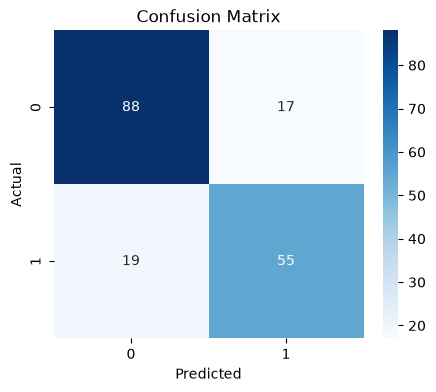

In [20]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
     


In [ ]:
## OBSERVATION 

The confusion matrix shows how many passengers were correctly and incorrectly classified by the model.

The majority of predictions were correct, indicating that the Random Forest model learned meaningful patterns from the dataset.

In [ ]:
## STEP 11 : CLASSIFFICATION REPORT 

In [ ]:
The classification report provides additional performance metrics such as precision, recall, and F1-score.

These metrics help evaluate the effectiveness of the model beyond overall accuracy.

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
## OBSERVATION 

The classification report provides a detailed evaluation of the model's performance.

The Random Forest model achieved good precision, recall, and F1-score, indicating reliable performance in predicting passenger survival.

In [ ]:
## CONCLUSION 

In this project, a Random Forest Classifier was used to predict passenger survival using the Titanic dataset.

## STEPS PERFORMED 
    
-> Loaded the dataset

-> Preprocessed the data

-> Handled missing values

-> Converted categorical variables into numerical values

-> Selected features and target variable

-> Split the dataset into training and testing sets

-> Trained a Random Forest Classifier

-> Evaluated the model using accuracy, confusion matrix, and classification report

In [ ]:
## RESULTS:-

-> Model Accuracy: 79.9%

-> The model successfully learned patterns from the dataset and predicted passenger survival with good accuracy.

In [ ]:
## TOOLS USED 

-> Python

-> Pandas

-> Scikit-learn

-> Matplotlib

-> Seaborn

-> Google Colab

In [ ]:
This project demonstrates the complete workflow of a supervised machine learning classification problem.